<h2>Получение данных</h2>

In [1]:
import pandas as pd
from load_data import dataframes

pd.set_option('display.max_column', 100)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', None)

for df_name, df in dataframes.items():
    print(f"\n=== {df_name} ===")
    print(df.info())
    print(df.head())
    print("\n" + "="*50)


=== basket_charged ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137685 entries, 0 to 137684
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   MAT_CODE        137685 non-null  int64         
 1   MAT_DEC         137685 non-null  object        
 2   HEATID          137685 non-null  object        
 3   DATETIME        137685 non-null  datetime64[ns]
 4   CHARGED_AMOUNT  137685 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 5.3+ MB
None
   MAT_CODE                 MAT_DEC  HEATID            DATETIME  CHARGED_AMOUNT
0    205051                      3A  6F0020 2016-01-01 18:51:00         54071.0
1    205051                      3A  6F0020 2016-01-01 19:24:00         75240.0
2    360258  In-house produced lime  6F0020 2016-01-01 18:33:00          2502.0
3    205051                      3A  6F0020 2016-01-01 18:51:00          4773.0
4    3602

Столбцы с датами были преобразованы в DateTime
Столбцы с вещественными числами преобразованы в float

ladle_tapping: 310 пропусков в DATETIME.

eaf_final_chemical_measurements: 368–1,292 пропуска в химических столбцах.

eaf_transformer
Сделаем DURATION (формат HH:MM) числовым (например, в минутах)

In [2]:
dataframes['eaf_transformer']['DURATION'] = pd.to_timedelta(dataframes['eaf_transformer']['DURATION'] + ':00', errors='coerce').dt.total_seconds() / 60
dataframes['eaf_transformer']

,TAP,HEATID,STARTTIME,DURATION,MW
0,11,6F0020,2016-01-01 18:35:00,29.0,0.500
1,17,6F0020,2016-01-01 19:04:00,640.0,16.000
2,17,6F0020,2016-01-01 18:55:00,180.0,11.000
3,17,6F0020,2016-01-01 18:37:00,800.0,16.750
4,17,6F0020,2016-01-01 18:36:00,40.0,0.750
...,...,...,...,...,...
271707,16,5F8442,2015-12-31 22:17:00,10.0,0.125
271708,16,5F8442,2015-12-31 22:04:00,10.0,0.000
271709,15,5F8442,2015-12-31 22:32:00,330.0,8.125
271710,15,5F8442,2015-12-31 22:29:00,91.0,2.125


In [3]:
dataframes['eaf_transformer']['DURATION'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 271712 entries, 0 to 271711
Series name: DURATION
Non-Null Count   Dtype  
--------------   -----  
271710 non-null  float64
dtypes: float64(1)
memory usage: 2.1 MB


ferro
Unnamed: 0 — лишний столбец, удалим

In [4]:
dataframes['ferro'] = dataframes['ferro'].drop(columns=['Unnamed: 0'])
dataframes['ferro']

,Description,Slagging,Nb,Ta,Mo,V,Ca,Al,Mg,P,S,Ash,Moisture,C,Si,Mn,Cr,Ti,Cu,Zn,Ni,Pb,Sn,Al2O3,CaO+MgO,CaO,SiO2,MgO,FeO,Fe2O3,Cr2O3,TiO2,Na+K,TiO,As,SiC,Zr,MAT_CODE
0,In-house produced lime,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,92.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,360258
1,MnSi17A,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.100000,0.000000,0.0,0.000000,0.000000,17.500000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,202007
2,FeCr025,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.030000,0.020000,0.0,0.000000,0.250000,2.000000,0.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,202034
3,Artificial graphite 0.1-2.5 mm,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.800000,14.0,2.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,203090
4,Al wire (APM),0,0.0,0.0,0.0,0.0,0.0,96.709870,0.797607,0.000000,0.000000,0.0,0.000000,0.000000,0.598205,0.797607,0.099701,0.199402,0.299103,0.299103,0.199402,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,323087
5,PP-SK30 wire,0,0.0,0.0,0.0,0.0,28.0,0.000000,0.000000,0.000000,0.000000,0.0,0.500000,0.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,202049
6,Secondary aluminum AV 87,0,0.0,0.0,0.0,0.0,0.0,84.493042,2.982107,0.000000,0.000000,0.0,0.000000,0.000000,4.970179,0.000000,0.000000,0.000000,3.777336,3.280318,0.000000,0.298211,0.198807,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,205069
7,FeSi65-4,0,0.0,0.0,0.0,0.0,0.0,2.000000,0.000000,0.050000,0.040000,0.0,0.000000,0.200000,65.500000,0.400000,0.400000,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,202008
8,Pellets AV-87,0,0.0,0.0,0.0,0.0,0.0,84.493042,2.982107,0.000000,0.000000,0.0,0.000000,0.000000,4.970179,0.000000,0.000000,0.000000,3.777336,3.280318,0.000000,0.298211,0.198807,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.00,205159
9,KRS-65 briquets,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,12.827988,36.151603,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,51.020408,0.00,202063


<h2>EDA</h2>


=== Анализ eaf_temp ===
Пропуски в eaf_temp:
TEMP         0
VALO2_PPM    0
dtype: int64

Базовая статистика для TEMP и VALO2_PPM:
               TEMP     VALO2_PPM
count  85104.000000  85104.000000
mean    1632.879841    891.918256
std       27.407976   1271.283796
min     1115.000000      0.000000
25%     1616.000000    579.000000
50%     1635.000000    797.000000
75%     1651.000000    990.000000
max     1850.000000   9999.000000


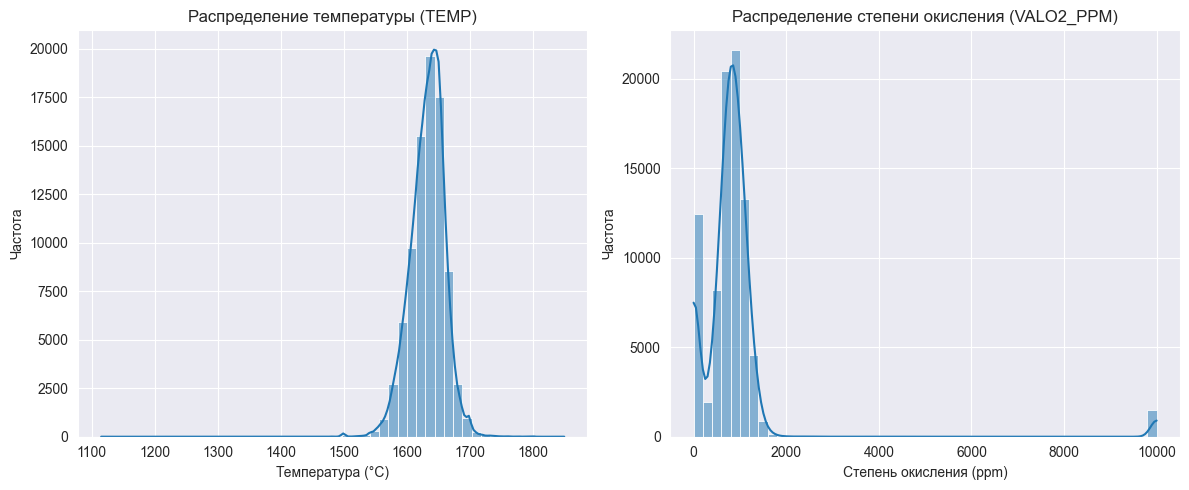

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df_temp = dataframes.get('eaf_temp')
print("\n=== Анализ eaf_temp ===")
# Пропуски
print("Пропуски в eaf_temp:")
print(df_temp[['TEMP', 'VALO2_PPM']].isna().sum())

# Базовая статистика
print("\nБазовая статистика для TEMP и VALO2_PPM:")
print(df_temp[['TEMP', 'VALO2_PPM']].describe())

# Гистограммы для TEMP и VALO2_PPM
plt.figure(figsize=(12, 5))

# Гистограмма для TEMP
plt.subplot(1, 2, 1)
sns.histplot(df_temp['TEMP'], bins=50, kde=True)
plt.title('Распределение температуры (TEMP)')
plt.xlabel('Температура (°C)')
plt.ylabel('Частота')

# Гистограмма для VALO2_PPM
plt.subplot(1, 2, 2)
sns.histplot(df_temp['VALO2_PPM'], bins=50, kde=True)
plt.title('Распределение степени окисления (VALO2_PPM)')
plt.xlabel('Степень окисления (ppm)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

TEMP (температура):

Среднее: 1632.88°C, медиана: 1635°C — температура стабильно в районе 1600–1650°C.

Минимум: 1115°C, максимум: 1850°C — минимальное значение кажется низким для рабочей печи.

Стандартное отклонение (27.41°C) небольшое, значит данные стабильны.

VALO2_PPM (степень окисления):

Среднее: 891.92 ppm, медиана: 797 ppm — средняя степень окисления умеренная.

Минимум: 0 ppm, максимум: 9999 ppm — нули объясняются описанием датасета (измерение не проводилось), а 9999 выглядит как аномалия.

Стандартное отклонение (1271.28) большое, что указывает на широкий разброс, возможно из-за нулей и выбросов.

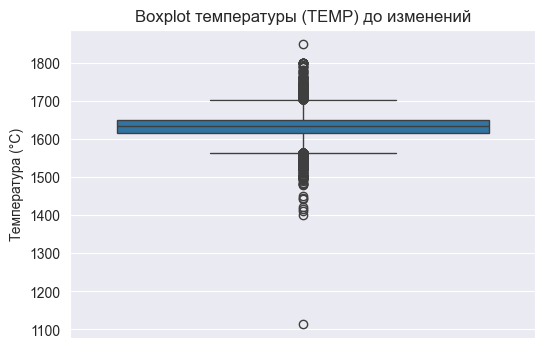

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_temp, y='TEMP')
plt.title('Boxplot температуры (TEMP) до изменений')
plt.ylabel('Температура (°C)')
plt.show()

Выбросы:

Сверху: значения до ~1820 °C — скорее всего, это пики при перегреве.

Снизу: значения ниже 1500 °C (включая один экстремальный выброс ~1100 °C) — скорее всего, ошибки измерения или очень ранние замеры на старте плавки.

In [9]:
# Количество нулей и значений 9999 в VALO2_PPM
total_rows = len(df_temp)
zeros_count = (df_temp['VALO2_PPM'] == 0).sum()
max_count = (df_temp['VALO2_PPM'] == 9999).sum()
zeros_fraction = zeros_count / total_rows * 100
max_fraction = max_count / total_rows * 100

print(f"\nКоличество нулей в VALO2_PPM: {zeros_count} ({zeros_fraction:.2f}%)")
print(f"Количество значений 9999 в VALO2_PPM: {max_count} ({max_fraction:.2f}%)")


Количество нулей в VALO2_PPM: 10116 (11.89%)
Количество значений 9999 в VALO2_PPM: 1485 (1.74%)


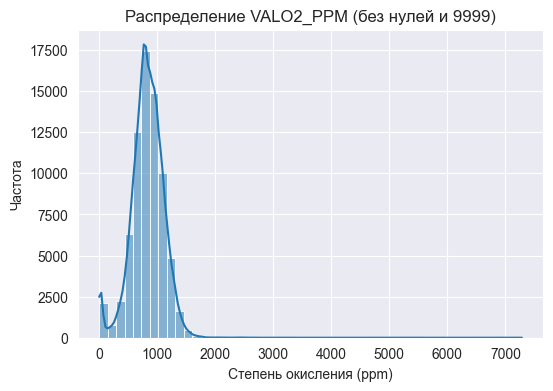

In [61]:
# Гистограмма VALO2_PPM без нулей и 9999
plt.figure(figsize=(6, 4))
sns.histplot(df_temp[(df_temp['VALO2_PPM'] > 0) & (df_temp['VALO2_PPM'] < 9999)]['VALO2_PPM'], bins=50, kde=True)
plt.title('Распределение VALO2_PPM (без нулей и 9999)')
plt.xlabel('Степень окисления (ppm)')
plt.ylabel('Частота')
plt.show()

Степень окисления (VALO2_PPM)

До очистки: куча нулей (это значит, что в момент измерения не брали образец на оксид, просто регистрировали температуру) и очень большое число «9999» (судя по всему, sentinel‑значение, когда датчик не сработал или не было данных).

После отсева нулей и 9999: распределение сильно скошено вправо, пиковая плотность около 600–1200 ppm, с длинным «хвостом» до ~2000 ppm и единичными точками дальше.

In [62]:
df_temp_clean = df_temp[(df_temp['VALO2_PPM'] > 0) & (df_temp['VALO2_PPM'] < 9999)].copy()

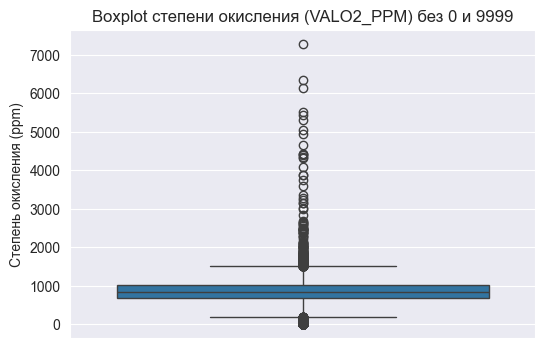

In [63]:
# Боксплот для окисления
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_temp_clean, y='VALO2_PPM')
plt.title('Boxplot степени окисления (VALO2_PPM) без 0 и 9999')
plt.ylabel('Степень окисления (ppm)')
plt.show()

Распределение степени окисления имеет асимметрию вправо

Возможна нормализация или логарифмическое преобразование признака перед подачей в модель для уменьшения влияния хвост

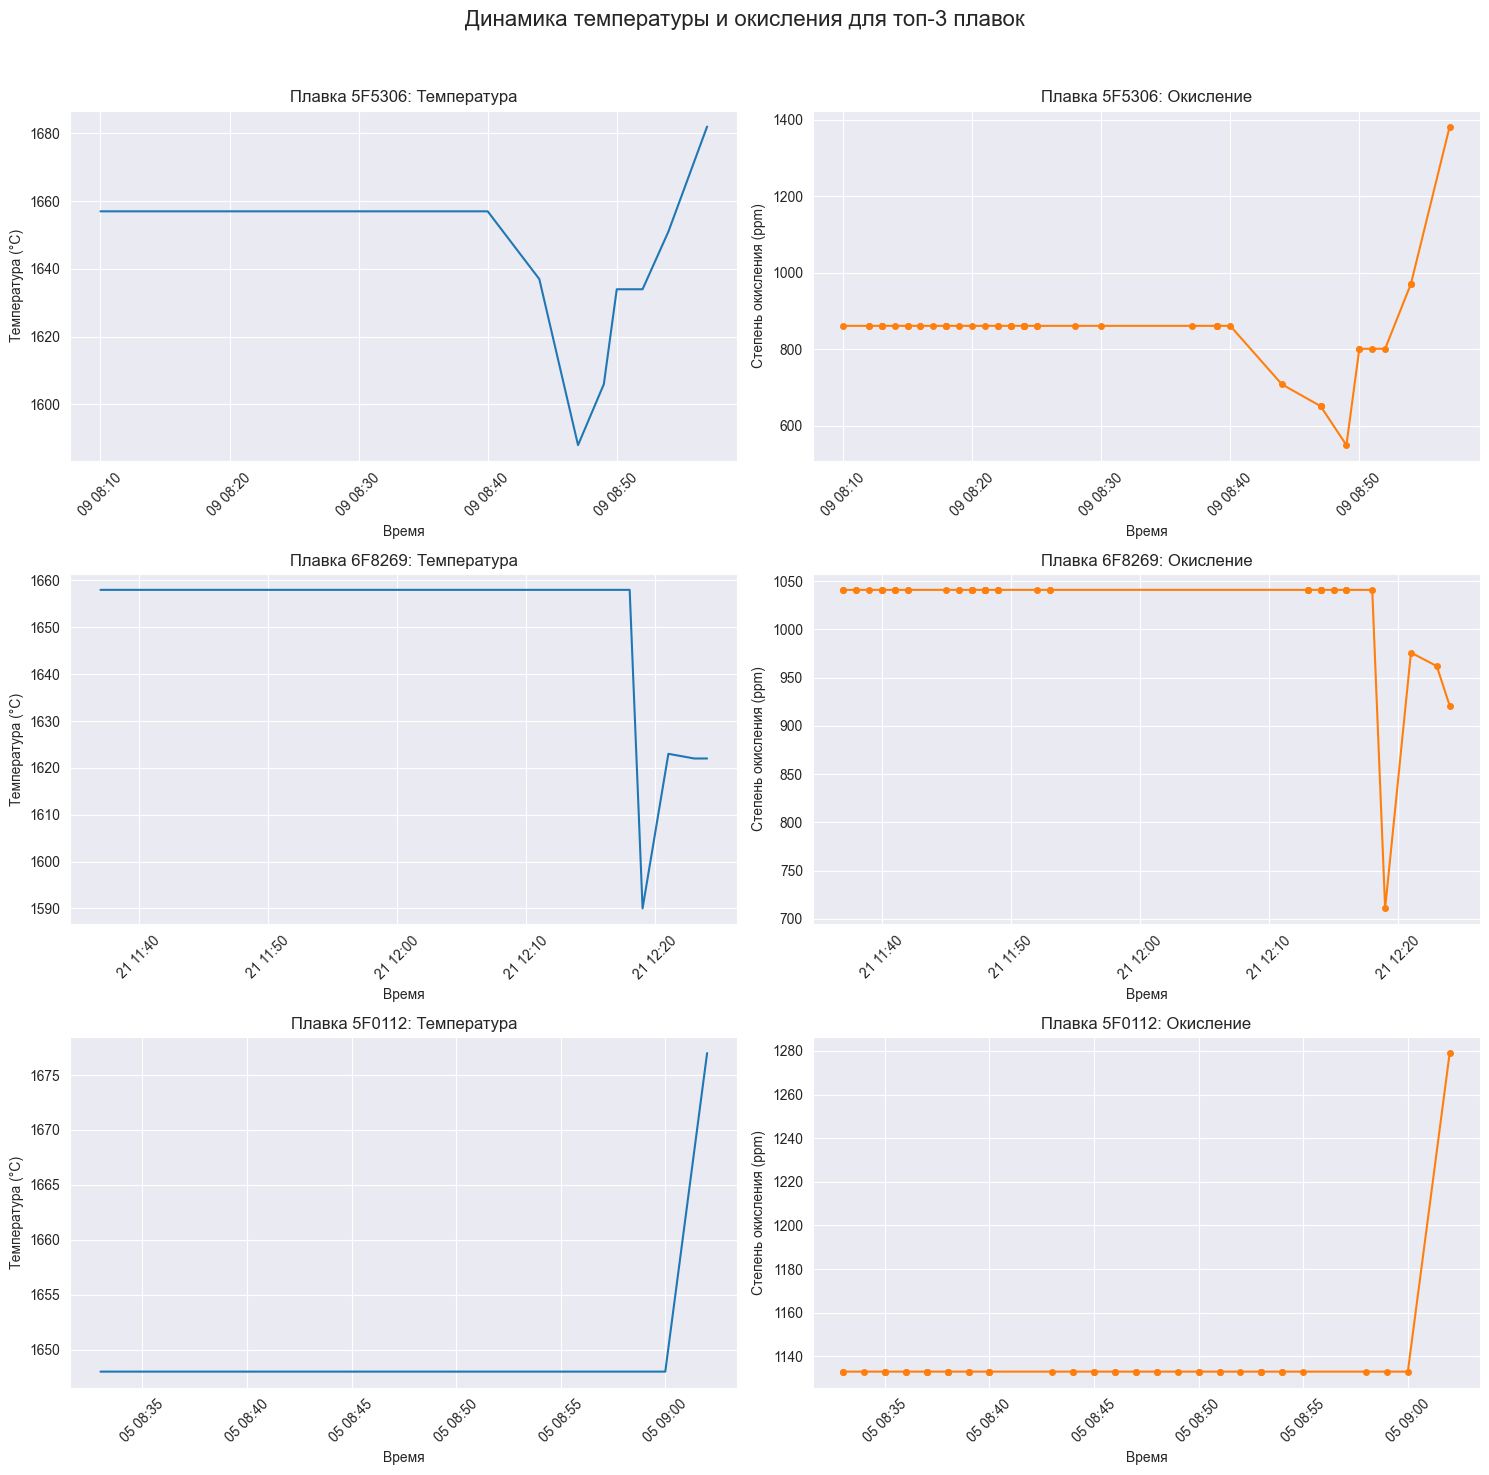

HEATID: 5F5306
  Количество измерений: 48
  Временной диапазон: 2015-08-09 08:10:00 - 2015-08-09 08:57:00
  Средняя температура: 1649.6°C
  Среднее окисление: 848.6 ppm
  Доля пропусков: 0.0%
--------------------------------------------------
HEATID: 6F8269
  Количество измерений: 48
  Временной диапазон: 2016-12-21 11:37:00 - 2016-12-21 12:24:00
  Средняя температура: 1654.4°C
  Среднее окисление: 1028.6 ppm
  Доля пропусков: 0.0%
--------------------------------------------------
HEATID: 5F0112
  Количество измерений: 46
  Временной диапазон: 2015-01-05 08:33:00 - 2015-01-05 09:02:00
  Средняя температура: 1648.6°C
  Среднее окисление: 1136.2 ppm
  Доля пропусков: 0.0%
--------------------------------------------------


In [25]:
# Находим топ-3 плавки по количеству измерений
top_heats = df_temp.groupby('HEATID').size().nlargest(3).index.tolist()

# Создаем фигуру с 3 строками и 2 столбцами
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
fig.suptitle('Динамика температуры и окисления для топ-3 плавок', fontsize=16)

for i, heat_id in enumerate(top_heats):
    df_heat = df_temp[df_temp['HEATID'] == heat_id].sort_values('DATETIME')

    # График температуры (левый столбец)
    ax_temp = axes[i, 0]
    ax_temp.plot(df_heat['DATETIME'], df_heat['TEMP'], color='#1f77b4')
    ax_temp.set_title(f'Плавка {heat_id}: Температура', fontsize=12)
    ax_temp.set_xlabel('Время')
    ax_temp.set_ylabel('Температура (°C)')
    ax_temp.grid(True)
    ax_temp.tick_params(axis='x', rotation=45)

    # График окисления (правый столбец)
    ax_ox = axes[i, 1]
    ax_ox.plot(df_heat['DATETIME'], df_heat['VALO2_PPM_clean'],
              color='#ff7f0e', marker='o', markersize=4)
    ax_ox.set_title(f'Плавка {heat_id}: Окисление', fontsize=12)
    ax_ox.set_xlabel('Время')
    ax_ox.set_ylabel('Степень окисления (ppm)')
    ax_ox.grid(True)
    ax_ox.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Вывод статистики для каждой плавки
for heat_id in top_heats:
    df_heat = df_temp[df_temp['HEATID'] == heat_id]
    print(f"HEATID: {heat_id}")
    print(f"  Количество измерений: {len(df_heat)}")
    print(f"  Временной диапазон: {df_heat['DATETIME'].min()} - {df_heat['DATETIME'].max()}")
    print(f"  Средняя температура: {df_heat['TEMP'].mean():.1f}°C")
    print(f"  Среднее окисление: {df_heat['VALO2_PPM_clean'].mean():.1f} ppm")
    print(f"  Доля пропусков: {df_heat['VALO2_PPM_clean'].isna().mean() * 100:.1f}%")
    print("-" * 50)

Резкие скачки температуры часто сопровождаются скачками окисления

In [64]:
import numpy as np

# Удаление строк с температурой меньше 1450 и больше 1800
df_temp_clean = df_temp_clean[df_temp_clean['TEMP'].between(1450, 1800, inclusive='both')]

# Замена значений температуры больше 1750 на 1750
df_temp_clean.loc[df_temp_clean['TEMP'] > 1750, 'TEMP'] = 1750

# Применение логарифмического преобразования для VALO2_PPM с использованием log1p
df_temp_clean['VALO2_PPM_log'] = np.log1p(df_temp_clean['VALO2_PPM'])

Корреляция между температурой и окислением (Pearson): 0.434


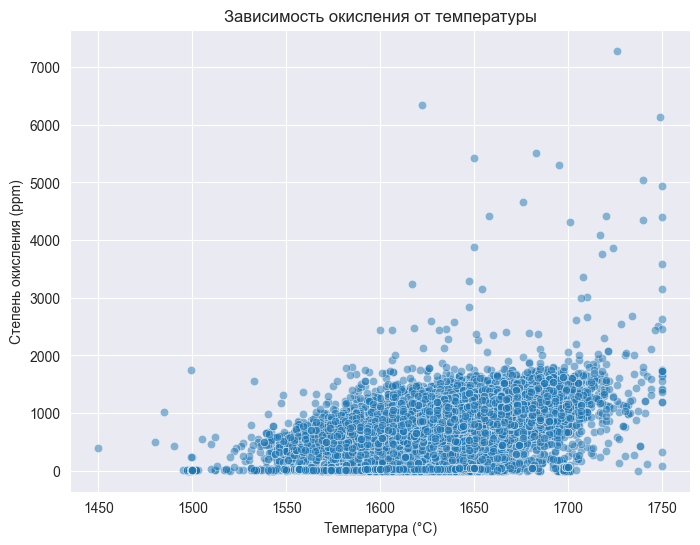

In [65]:
# Корреляция между TEMP и VALO2_PPM
correlation = df_temp_clean['TEMP'].corr(df_temp_clean['VALO2_PPM_clean'], method='pearson')
print(f"Корреляция между температурой и окислением (Pearson): {correlation:.3f}")

# Визуализация корреляции
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_temp_clean, x='TEMP', y='VALO2_PPM_clean', alpha=0.5)
plt.title('Зависимость окисления от температуры')
plt.xlabel('Температура (°C)')
plt.ylabel('Степень окисления (ppm)')
plt.grid(True)
plt.show()

Корреляция Пирсона 0.434 между температурой (TEMP) и окислением (VALO2_PPM_log) указывает на умеренную положительную линейную связь. Это подтверждает, что повышение температуры в EAF, вероятно, усиливает окислительные процессы, что логично для металлургии.

Однако значение менее 0.5 говорит о том, что связь не является доминирующей, и на окисление могут влиять и другие факторы. Для моделирования стоит учитывать возможную мультиколлинеарность, но она не критична на данном уровне.

Размер DataFrame: (3709, 15)

Первые 5 строк данных:
   HEATID  POSITIONROW            DATETIME    VALC   VALSI   VALMN    VALP    VALS   VALCU   VALCR   VALMO   VALNI   VALAS   VALSN    VALN
0  6F0037            1 2016-01-02 11:02:00  0.0545  0.0197  0.0632  0.0040  0.0210  0.2145  0.0504  0.0165  0.1307  0.0064  0.0209  0.0124
1  6F0042            1 2016-01-02 15:22:00  0.0692  0.0167  0.0598  0.0042  0.0158  0.2278  0.0864  0.0166  0.1684  0.0064  0.0072  0.0110
2  6F0045            1 2016-01-02 18:05:00  0.0558  0.0169  0.0666  0.0053  0.0203  0.2315  0.1100  0.0176  0.1790  0.0063  0.0107  0.0105
3  6F0096            1 2016-01-04 17:30:00  0.0620  0.0156  0.0811  0.0046  0.0211  0.1677  0.0596  0.0112  0.0948  0.0061  0.0055  0.0118
4  6F0098            1 2016-01-04 19:19:00  0.0501  0.0144  0.0604  0.0054  0.0251  0.1850  0.0448  0.0111  0.1033  0.0064  0.0061  0.0133

Пропуски в химических данных:
VALC      368
VALSI     368
VALMN     368
VALP      369
VALS      368
VALCU     36

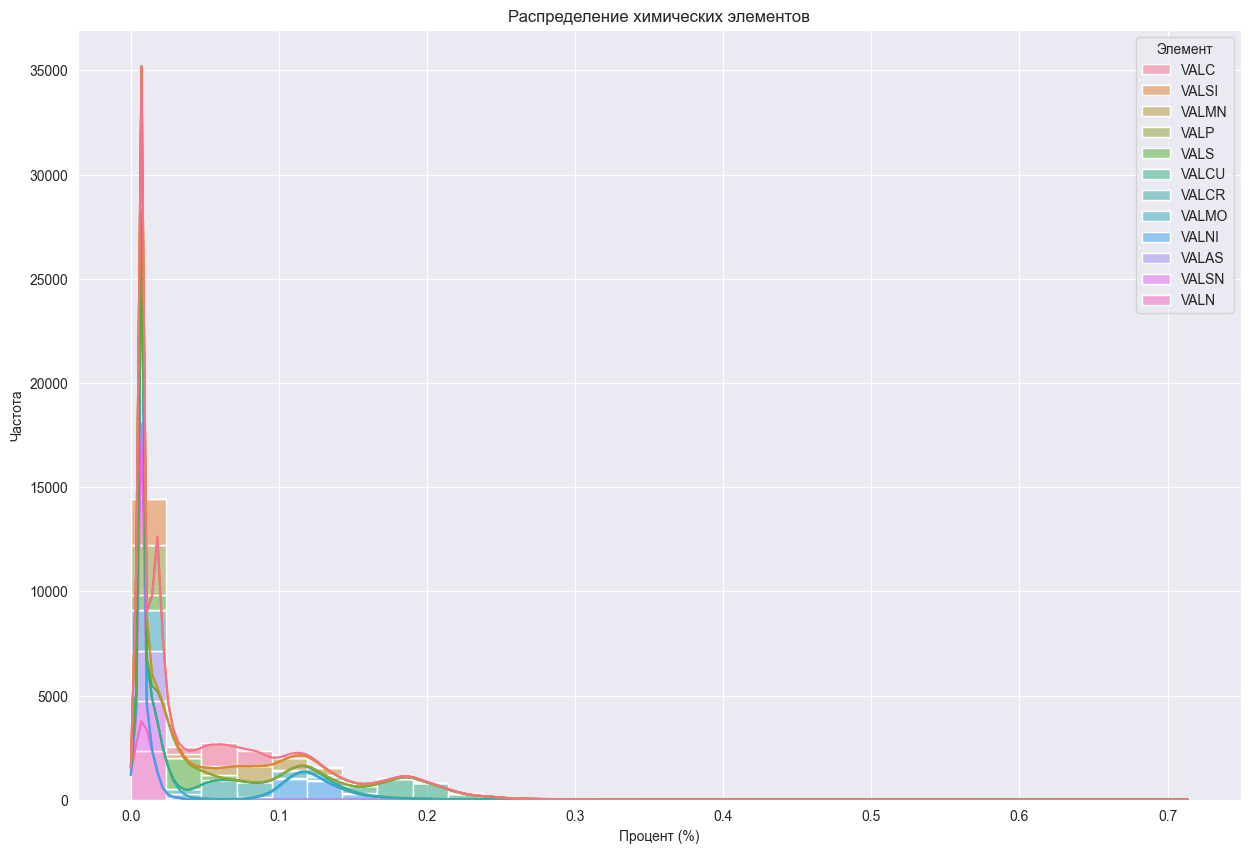

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Загружаем данные
df_chem = dataframes.get('eaf_final_chemical_measurements')

print("Размер DataFrame:", df_chem.shape)
print("\nПервые 5 строк данных:")
print(df_chem.head())

# Пропуски
print("\nПропуски в химических данных:")
print(df_chem.drop(columns=['HEATID', 'DATETIME', 'POSITIONROW']).isna().sum())

# Удаляем строки, где все химические элементы NaN
df_chem_numeric = df_chem.drop(columns=['HEATID', 'DATETIME', 'POSITIONROW'])
df_chem_numeric = df_chem_numeric.dropna(how='all')

# Фильтруем аномалии (значения >10% считаем ошибочными для химии стали)
df_chem_numeric = df_chem_numeric[df_chem_numeric < 1].dropna()

# Базовая статистика
print("\nБазовая статистика для химических элементов:")
print(df_chem_numeric.describe())

# Гистограммы для всех химических элементов
melted_df = df_chem_numeric.melt(var_name='Элемент', value_name='Значение')
print("\nРазмер melted_df:", melted_df.shape)
print("\nПервые 5 строк melted_df:")
print(melted_df.head())

plt.figure(figsize=(15, 10))
sns.histplot(data=melted_df, x='Значение', hue='Элемент', multiple='stack', bins=30, kde=True)
plt.title('Распределение химических элементов')
plt.xlabel('Процент (%)')
plt.ylabel('Частота')
plt.show()

Распределение сильно смещено влево (правостороннее):

Большинство значений сосредоточено около 0–0.05%.

Это говорит о низком содержании легирующих примесей в составе.

Есть длинные хвосты справа:

У некоторых элементов есть значения > 0.2%, доходящие даже до 0.7%.

Это могут быть аномалии, ошибки анализа, либо отдельные партии легированных сталей (например, с повышенным содержанием Ni, Mo и пр.).


VALC, VALMN и VALSI — наиболее выраженные: их распределение шире, и они, вероятно, чаще используются как регулярные легирующие компоненты.

VALCU, VALCR, VALMO и VALNI — могут быть целевыми для предсказания, особенно если они варьируются от партии к партии.


Доля нулевых значений (в %):
VALC     0.0
VALSI    0.0
VALMN    0.0
VALP     0.0
VALS     0.0
VALCU    0.0
VALCR    0.0
VALMO    0.0
VALNI    0.0
VALAS    0.0
VALSN    0.0
VALN     0.0
dtype: float64


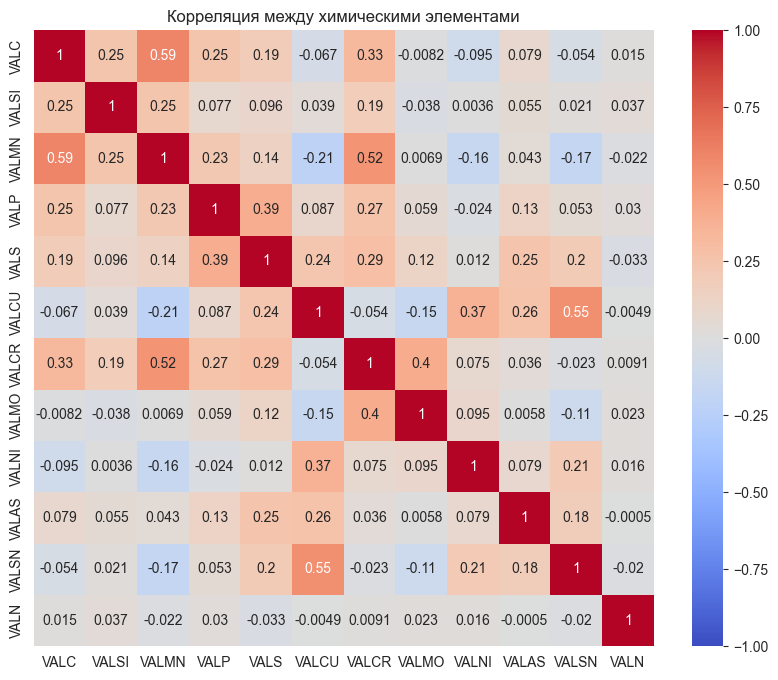

In [50]:
df_chem_numeric = df_chem.drop(columns=['HEATID', 'DATETIME', 'POSITIONROW'])
df_chem_numeric = df_chem_numeric.dropna(how='all')
df_chem_numeric = df_chem_numeric[df_chem_numeric < 1].dropna()

# Доля нулевых значений
zero_percentage = (df_chem_numeric == 0).mean() * 100
print("\nДоля нулевых значений (в %):")
print(zero_percentage)

# Корреляционная матрица
corr_matrix = df_chem_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляция между химическими элементами')
plt.show()

В целом, большинство коэффициентов корреляции невелики, что указывает на относительную независимость большинства элементов в составе.

Наиболее выраженные положительные корреляции:

VALC и VALMN: r = 0.59

Углерод и марганец влияют на прочность и могут дозироваться совместно.

VALCR и VALCU: r = 0.55

Возможный признак специальных легированных сталей (например, нержавеющих).

VALMN и VALCR: r = 0.52

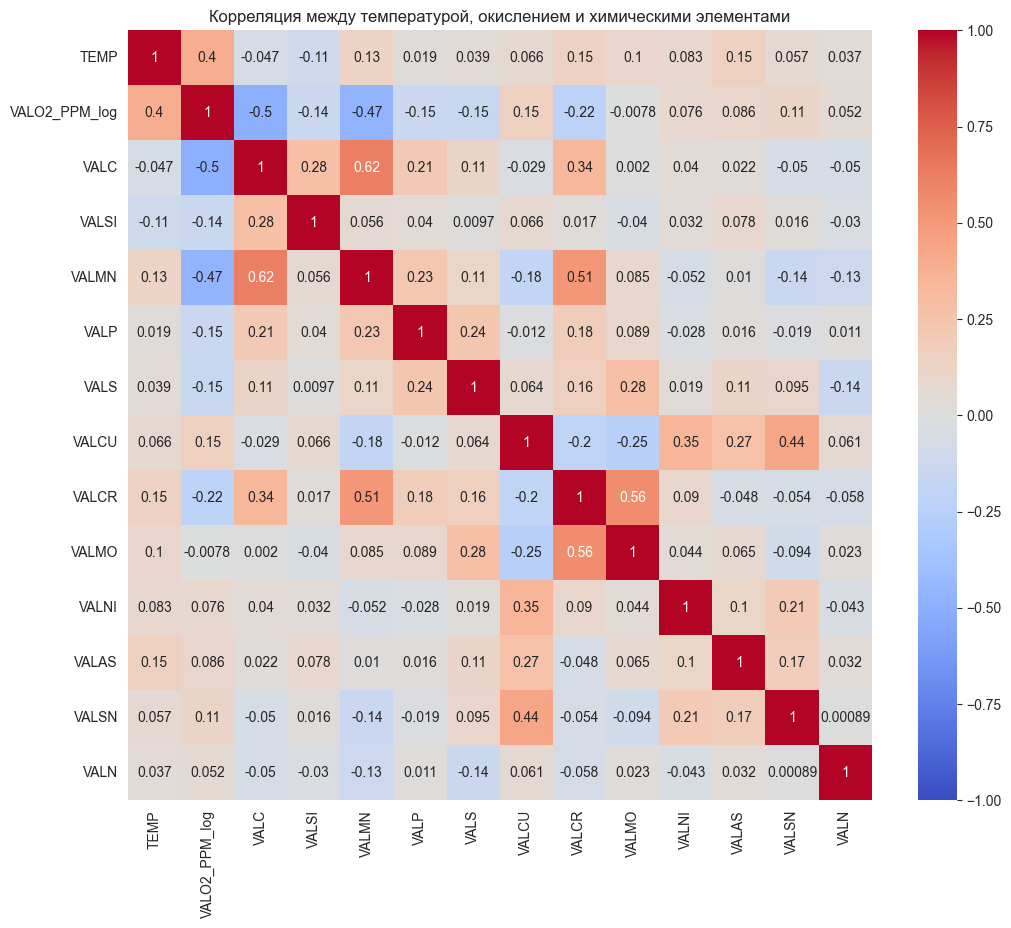


Типы данных в df_combined_numeric:
TEMP             float64
VALO2_PPM_log    float64
VALC             float64
VALSI            float64
VALMN            float64
VALP             float64
VALS             float64
VALCU            float64
VALCR            float64
VALMO            float64
VALNI            float64
VALAS            float64
VALSN            float64
VALN             float64
dtype: object


In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Предполагаем, что df_temp_clean уже очищен
df_temp_selected = df_temp_clean[['HEATID', 'DATETIME', 'TEMP', 'VALO2_PPM_log']]

# Объединяем таблицы
df_combined = pd.merge(df_temp_selected, df_chem, on=['HEATID', 'DATETIME'], how='inner')

# Выбираем числовые столбцы, исключая нечисловые
df_combined_numeric = df_combined.drop(columns=['HEATID', 'DATETIME', 'POSITIONROW'])

# Удаляем строки, где все значения NaN
df_combined_numeric = df_combined_numeric.dropna(how='all')

# Корреляционная матрица

corr_matrix = df_combined_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляция между температурой, окислением и химическими элементами')
plt.show()


# Диагностика типов данных
print("\nТипы данных в df_combined_numeric:")
print(df_combined_numeric.dtypes)

Сильные отрицательные корреляции наблюдаются с:

VALC	–0.50
VALMN	–0.47

Также наблюдаются

VALCR	–0.22
VALP	–0.15

Это означает, что при увеличении содержания углерода, марганца, хрома и фосфора степень окисления уменьшается.

Температура слабо положительно связана с содержанием серы и хрома.

Наблюдаются группы сильно коррелирующих элементов, что важно учитывать при дальнейшем анализе или моделировании

<h3>Корреляции с другими признаками</h3>


Топ-10 корреляций с очищенной температурой (по модулю):
TEMP             1.000000
CHARGE_AMOUNT    0.214809
VALAS            0.130742
VALCR            0.120773
VALMO            0.109674
VALSI           -0.100516
VALCU            0.082427
VALSN            0.079639
VALC            -0.075018
TAP              0.071663
Name: TEMP, dtype: float64


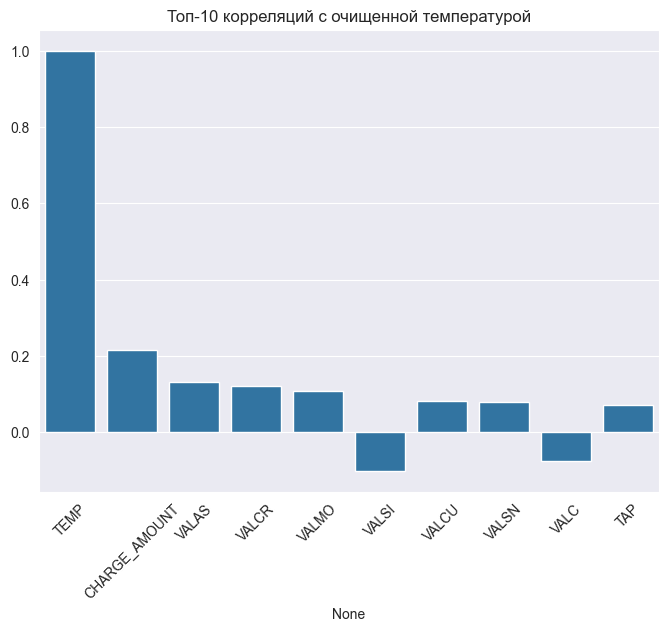


Топ-10 корреляций с логарифмическим окислением (по модулю):
VALO2_PPM_log    1.000000
VALO2_PPM        0.889400
VALC            -0.467391
VALMN           -0.428391
TEMP             0.413007
VALCR           -0.204180
VALP            -0.157819
VALCU            0.155303
VALS            -0.147853
VALSI           -0.124605
Name: VALO2_PPM_log, dtype: float64


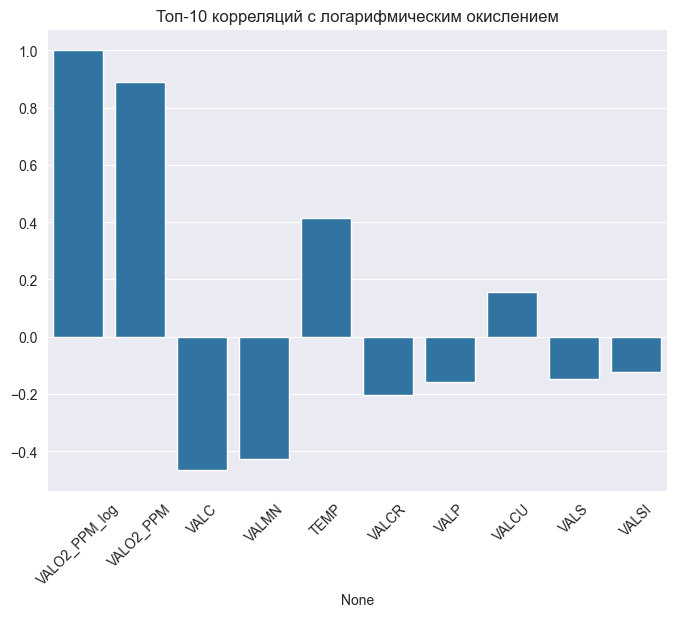

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загружаем данные
dataframes = {
    'eaf_final_chemical_measurements': dataframes['eaf_final_chemical_measurements'],
    'eaf_temp': dataframes['eaf_temp'],
    'eaf_transformer': dataframes['eaf_transformer'],
    'inj_mat': dataframes['inj_mat'],
    'eaf_gaslance_mat': dataframes['eaf_gaslance_mat'],
    'basket_charged': dataframes['basket_charged'],
    'ladle_tapping': dataframes['ladle_tapping'],
    'eaf_added_materials': dataframes['eaf_added_materials'],
    'lf_added_materials': dataframes['lf_added_materials']
}

# 1. Объединяем все таблицы в исходную (df_initial)
df_initial = dataframes['eaf_final_chemical_measurements'].merge(
    dataframes['eaf_temp'], on=['HEATID', 'DATETIME'], how='left', suffixes=('', '_temp')
).merge(
    dataframes['eaf_transformer'], on='HEATID', how='left'
).merge(
    dataframes['inj_mat'].groupby('HEATID').agg({'INJ_AMOUNT_CARBON': 'sum'}).reset_index(), on='HEATID', how='left'
).merge(
    dataframes['eaf_gaslance_mat'].groupby('HEATID').agg({'O2_AMOUNT': 'sum', 'GAS_AMOUNT': 'sum'}).reset_index(), on='HEATID', how='left'
)

# Агрегация материалов
df_materials = pd.concat([dataframes['basket_charged'], dataframes['ladle_tapping'],
                         dataframes['eaf_added_materials'], dataframes['lf_added_materials']])
material_agg = df_materials.groupby('HEATID').agg({'CHARGE_AMOUNT': 'sum', 'MAT_DEC': lambda x: x.mode()[0] if not x.empty else None}).reset_index()
df_initial = df_initial.merge(material_agg, on='HEATID', how='left')

# Преобразование категориальных признаков
df_initial = pd.get_dummies(df_initial, columns=['MAT_DEC'], drop_first=True)

# 2. Очистка температуры и корреляции
df_temp_clean = df_initial.copy()
df_temp_clean = df_temp_clean.dropna(subset=['TEMP'])  # Удаляем строки без температуры
df_temp_clean = df_temp_clean[(df_temp_clean['TEMP'] >= 1450) & (df_temp_clean['TEMP'] <= 1800)]  # Фильтр по температуре
df_temp_clean.loc[df_temp_clean['TEMP'] > 1750, 'TEMP'] = 1750  # Ограничение выше 1750

# Корреляции с очищенной температурой
temp_corr = df_temp_clean.select_dtypes(include=['float64', 'int64']).corr()['TEMP'].sort_values(ascending=False)
temp_corr_abs = temp_corr.abs().sort_values(ascending=False)  # Сортировка по модулю
top_10_temp = temp_corr.loc[temp_corr_abs.head(10).index]  # Берем топ-10 по модулю с истинными значениями
print("\nТоп-10 корреляций с очищенной температурой (по модулю):")
print(top_10_temp)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_10_temp.index, y=top_10_temp.values)
plt.xticks(rotation=45)
plt.title('Топ-10 корреляций с очищенной температурой')
plt.show()

# 3. Логарифмическое преобразование окисления и корреляции
df_ox_clean = df_initial.copy()
df_ox_clean = df_ox_clean.dropna(subset=['VALO2_PPM'])  # Удаляем строки без окисления
df_ox_clean = df_ox_clean[(df_ox_clean['VALO2_PPM'] != 0) & (df_ox_clean['VALO2_PPM'] != 9999)]  # Убираем 0 и 9999
df_ox_clean['VALO2_PPM_log'] = np.log1p(df_ox_clean['VALO2_PPM'])  # Логарифмическое преобразование

# Корреляции с логарифмическим окислением
ox_corr = df_ox_clean.select_dtypes(include=['float64', 'int64']).corr()['VALO2_PPM_log'].sort_values(ascending=False)
ox_corr_abs = ox_corr.abs().sort_values(ascending=False)  # Сортировка по модулю
top_10_ox = ox_corr.loc[ox_corr_abs.head(10).index]  # Берем топ-10 по модулю с истинными значениями
print("\nТоп-10 корреляций с логарифмическим окислением (по модулю):")
print(top_10_ox)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_10_ox.index, y=top_10_ox.values)
plt.xticks(rotation=45)
plt.title('Топ-10 корреляций с логарифмическим окислением')
plt.show()


Корреляции с температурой (TEMP)

Ключевые корреляции:

CHARGE_AMOUNT (0.2148): Это общий вес добавок из таблиц. Корреляция может указывать на то, что больший заряд способствует нагреву, возможно, из-за увеличения массы материала для нагрева.

Слабые корреляции могут быть связаны с нелинейными эффектами.


Окисление сильно зависит от химического состава (особенно углерода и марганца) и температуры, что согласуется с металлургическими процессами в электро-дуговой печи.


Топ-10 корреляций с VALC (по модулю):
TEMP                 0.127362
GAS_AMOUNT           0.084716
TAP                  0.083484
INJ_AMOUNT_CARBON    0.078094
O2_AMOUNT            0.064328
DURATION             0.027759
CHARGE_AMOUNT        0.022378
MW                   0.015845
VALO2_PPM            0.013971
POSITIONROW               NaN
Name: VALC, dtype: float64

Топ-10 корреляций с VALSI (по модулю):
TEMP                 0.114429
TAP                  0.044072
GAS_AMOUNT           0.037214
O2_AMOUNT            0.034735
INJ_AMOUNT_CARBON    0.031686
VALO2_PPM            0.020105
DURATION             0.016508
MW                   0.011825
CHARGE_AMOUNT        0.001268
POSITIONROW               NaN
Name: VALSI, dtype: float64

Топ-10 корреляций с VALMN (по модулю):
TAP                  0.100973
INJ_AMOUNT_CARBON    0.066794
O2_AMOUNT            0.055081
GAS_AMOUNT           0.052958
CHARGE_AMOUNT        0.047480
VALO2_PPM            0.043362
TEMP                 0.038042
DURATION        

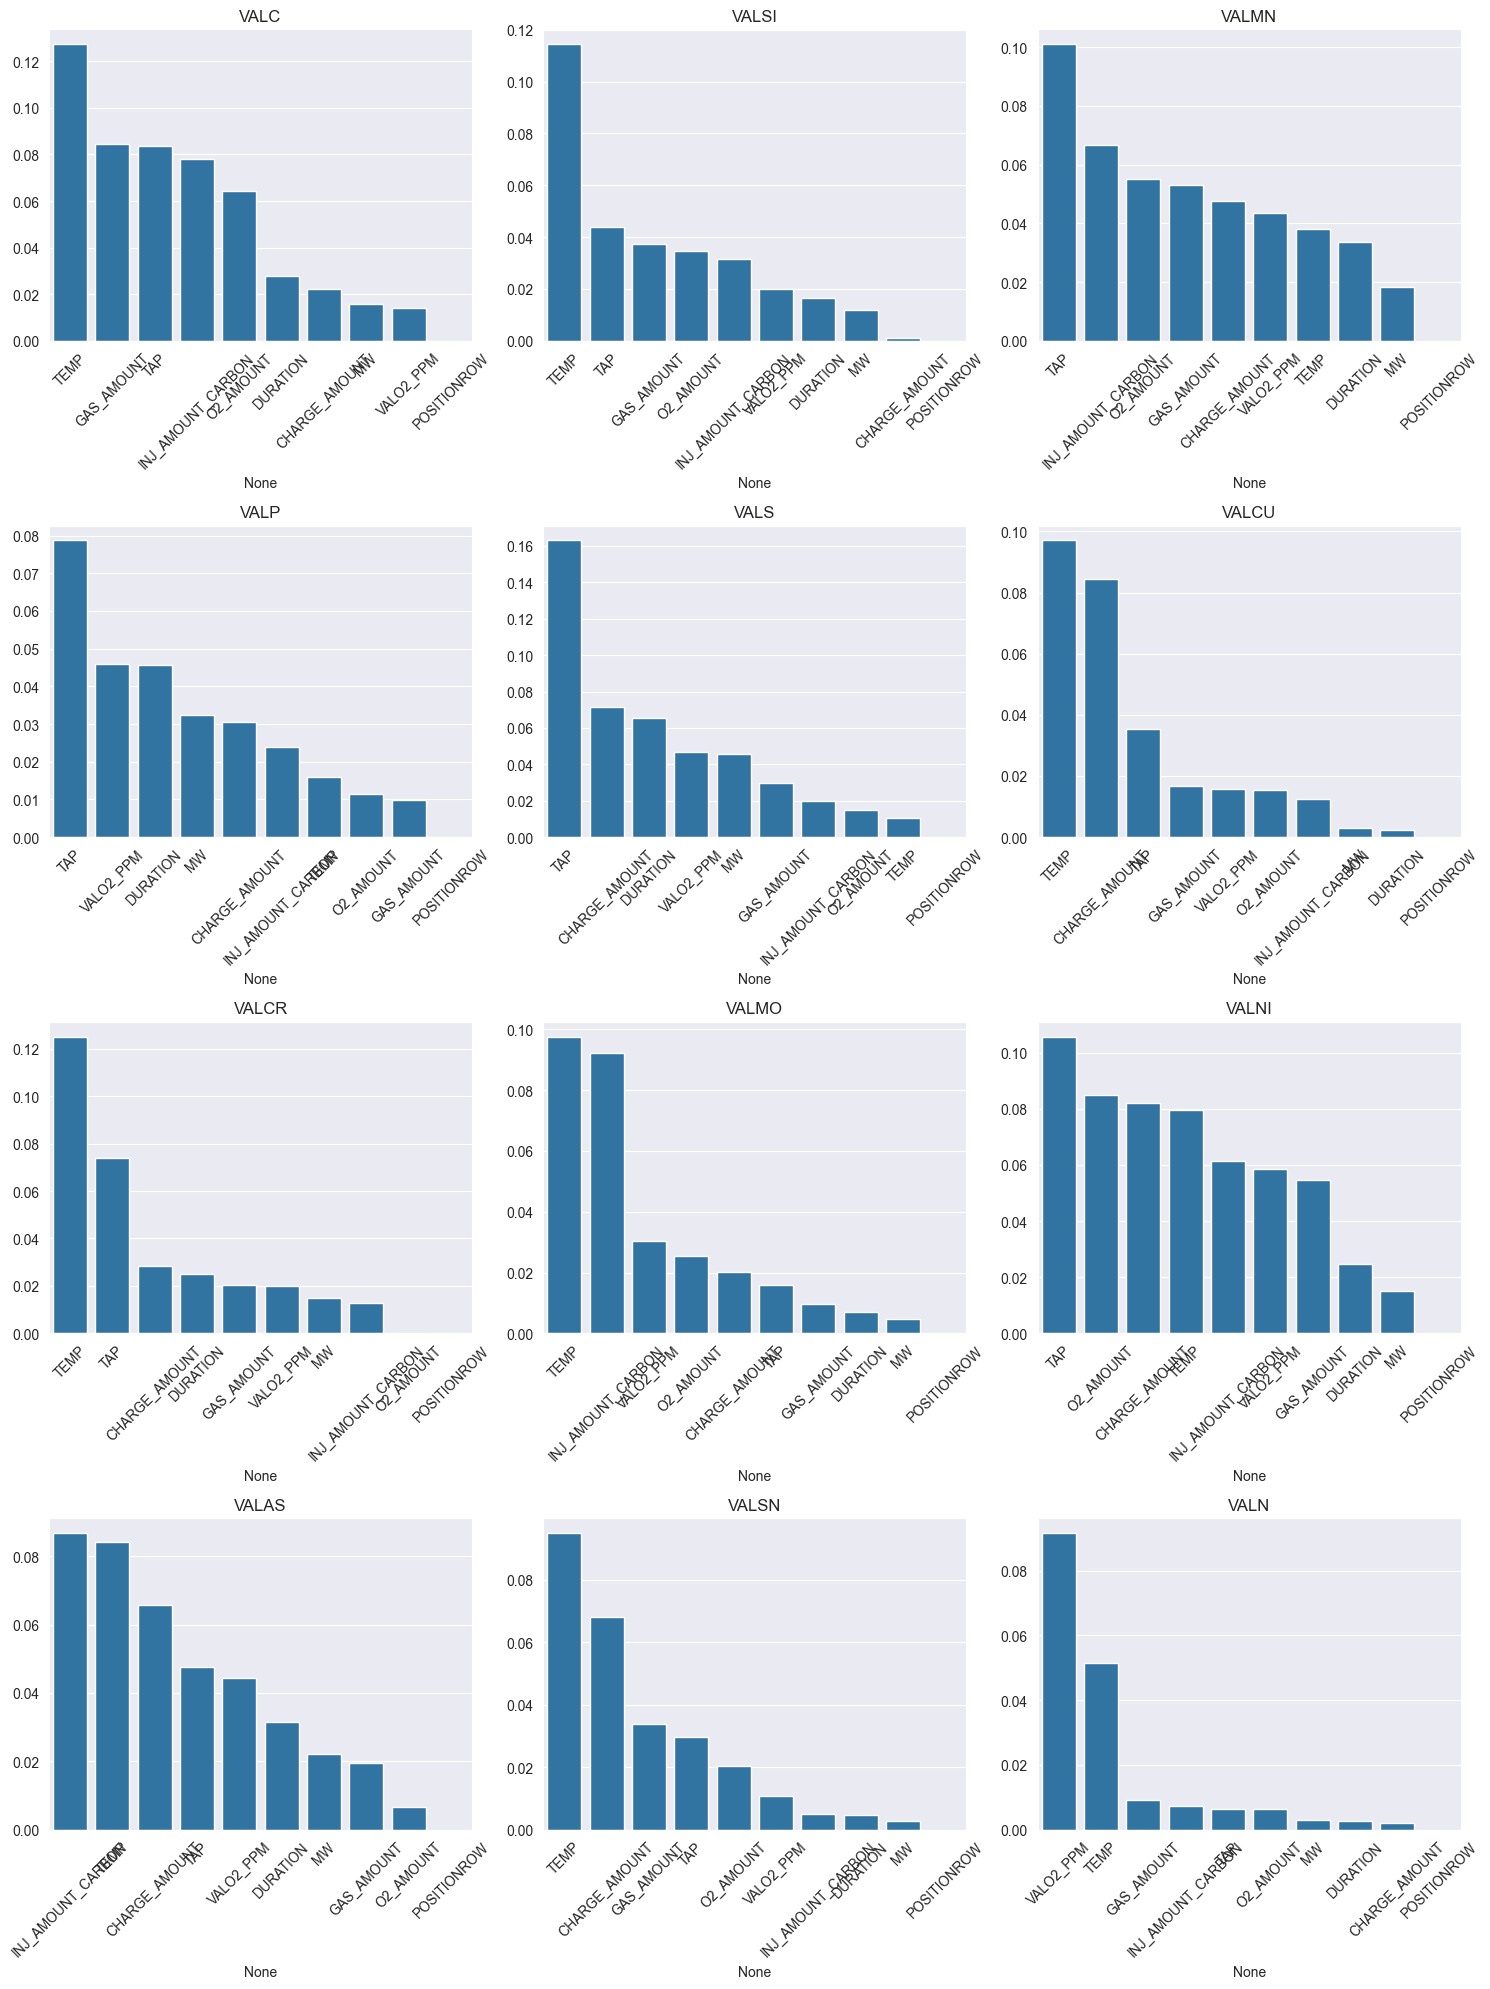

In [73]:
# 4. Корреляции исходной таблицы с химическими элементами
df_chem_initial = df_initial.dropna(subset=['VALC', 'VALSI', 'VALMN', 'VALP', 'VALS', 'VALCU', 'VALCR', 'VALMO', 'VALNI', 'VALAS', 'VALSN', 'VALN'])
numeric_cols_initial = df_chem_initial.select_dtypes(include=['float64', 'int64']).columns
chem_elements = ['VALC', 'VALSI', 'VALMN', 'VALP', 'VALS', 'VALCU', 'VALCR', 'VALMO', 'VALNI', 'VALAS', 'VALSN', 'VALN']
other_cols = [col for col in numeric_cols_initial if col not in chem_elements]  # Исключаем сами химические элементы

# Создаём общую фигуру с подграфиками
n_chem = len(chem_elements)
n_cols = 3  # Количество столбцов в сетке
n_rows = (n_chem + n_cols - 1) // n_cols  # Количество строк, округление вверх
plt.figure(figsize=(15, 5 * n_rows))

# Вычисляем и выводим топ-10 корреляций для каждого химического элемента
for i, chem in enumerate(chem_elements, 1):
    corr_with_chem = df_chem_initial[numeric_cols_initial].corr()[chem].abs().sort_values(ascending=False)
    top_10_chem = corr_with_chem.loc[corr_with_chem.index.isin(other_cols)].head(10)  # Только корреляции с другими признаками
    print(f"\nТоп-10 корреляций с {chem} (по модулю):")
    print(top_10_chem)

    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=top_10_chem.index, y=top_10_chem.values)
    plt.xticks(rotation=45)
    plt.title(f'{chem}')
    plt.tight_layout()  # Автоматическая настройка расстояний между подграфиками

plt.show()

Корреляции с химическими элементами

TAP: Стадия трансформатора из eaf_transformer.csv часто коррелирует с элементами (например, 0.163 с VALS, 0.101 с VALMN). Это может отражать влияние электрической мощности на финальные стадии плавки.


Слабые корреляции с параметрами процесса (например, TAP, CHARGE_AMOUNT) указывают на доминирование неучтённых факторов (например, динамики процесса), необходимость  новых(преобразованных) признаков или нелинейности зависимостей.